In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv


In [2]:
import pandas as pd 
df = pd.read_csv("/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df = df.drop("CustomerID",axis=1)

In [6]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

In [8]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [9]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [10]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
    model = KMeans(n_clusters = i,random_state = 42)
    model.fit(scaled_data)
    wcss.append(model.inertia_)

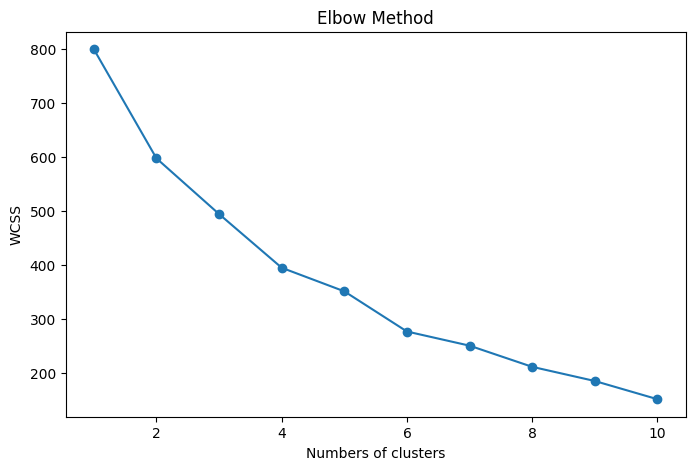

In [11]:
import matplotlib.pyplot as plt 
import seaborn as sns 
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker ='o')
plt.title("Elbow Method")
plt.xlabel("Numbers of clusters")
plt.ylabel("WCSS")
plt.show()

In [12]:
kmeans =  KMeans(n_clusters = 6 ,random_state = 42)
clusters = kmeans.fit_predict(scaled_data)

In [13]:
clusters

array([2, 2, 4, 4, 4, 4, 5, 4, 0, 4, 0, 4, 5, 4, 0, 2, 4, 2, 0, 4, 0, 2,
       5, 2, 5, 2, 5, 2, 5, 4, 0, 4, 0, 2, 5, 4, 5, 4, 5, 4, 5, 2, 0, 4,
       5, 4, 5, 4, 4, 4, 5, 2, 4, 0, 5, 0, 5, 0, 4, 0, 0, 2, 5, 5, 0, 2,
       5, 5, 2, 4, 0, 5, 5, 5, 0, 2, 5, 2, 4, 5, 0, 2, 0, 5, 4, 0, 5, 4,
       4, 5, 5, 2, 0, 5, 4, 2, 5, 4, 0, 2, 4, 5, 0, 2, 0, 4, 5, 0, 0, 0,
       0, 4, 5, 2, 4, 4, 5, 5, 5, 5, 2, 5, 3, 2, 4, 3, 1, 2, 0, 2, 1, 2,
       4, 3, 1, 3, 5, 2, 1, 3, 5, 2, 3, 3, 1, 2, 1, 3, 5, 2, 1, 2, 5, 3,
       5, 3, 1, 3, 1, 3, 5, 3, 1, 3, 1, 3, 1, 3, 5, 2, 1, 2, 1, 2, 5, 3,
       1, 2, 1, 2, 3, 3, 1, 3, 3, 2, 5, 2, 1, 3, 3, 3, 1, 3, 1, 3, 3, 3,
       1, 3], dtype=int32)

In [14]:
from sklearn.metrics import(silhouette_score,davies_bouldin_score,calinski_harabasz_score)
print("Silhotte_Score :",silhouette_score(scaled_data,clusters))
print("Davies_bouldin_score :",davies_bouldin_score(scaled_data,clusters))
print("Calinski_Harabasz_score :",calinski_harabasz_score(scaled_data,clusters))



Silhotte_Score : 0.3347543475669217
Davies_bouldin_score : 1.0139617115807866
Calinski_Harabasz_score : 73.10031750195824
